Model file found at: /home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_20241007_184255.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.0351, True: 0.0000
Predicted: 0.0351, True: 0.0000
Predicted: 0.0352, True: 0.0000
Predicted: 0.0353, True: 0.0000
Predicted: 0.0354, True: 0.0000
Predicted: 0.0355, True: 0.0000
Predicted: 0.0355, True: 0.0000
Predicted: 0.0355, True: 0.0000
Predicted: 0.0356, True: 0.0000
Predicted: 0.0356, True: 0.0000

Output Stats: min=0.0170, max=0.1408, mean=0.0471
Label Stats: min=0.0000, max=0.7700, mean=0.0463


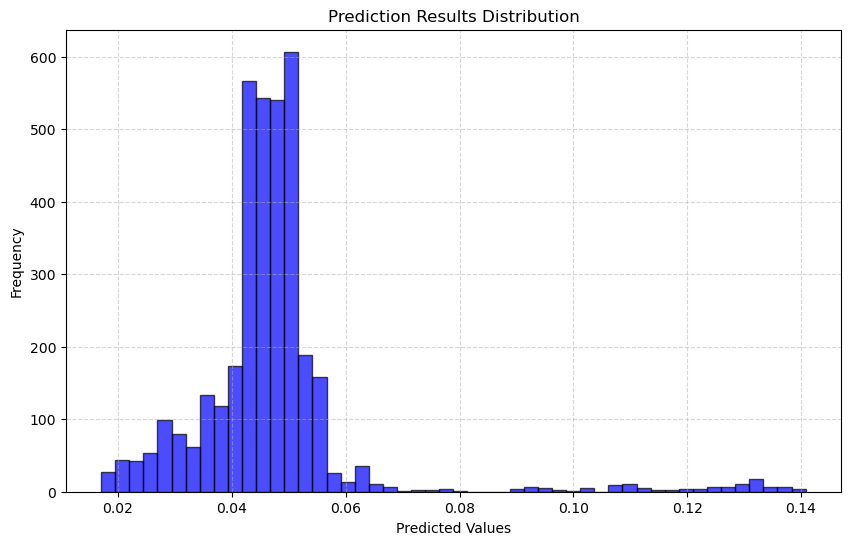

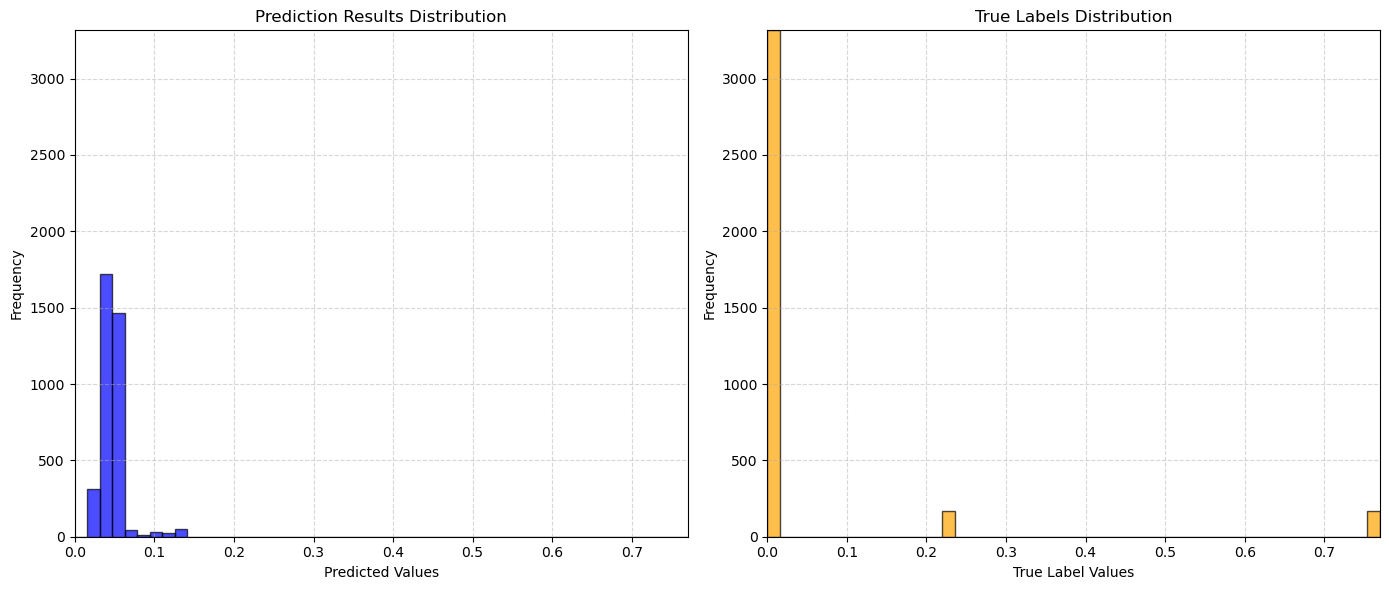

In [2]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin_src.weight)
        torch.nn.init.xavier_uniform_(m.lin_dst.weight)

# GATモデルの定義 (5層)
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_20241007_184255.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy().flatten()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    """
    予測結果と教師データの分布を並べてヒストグラムで可視化し、
    横軸と縦軸を揃える関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - label_file_path (str): 教師データ（ラベル）のファイルパス。
    """
    # 教師データの読み込み
    true_labels = np.load(label_file_path)[:3654]  # 必要な範囲を指定
    # 予測結果の取得
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 両方のデータの最小値と最大値を計算
    combined_min = min(output_np.min(), true_labels.min())
    combined_max = max(output_np.max(), true_labels.max())

    # ビンの設定（両方のデータに共通のビンを使用）
    bins = np.linspace(combined_min, combined_max, 50)

    # 予測結果のヒストグラムの最大頻度を計算
    hist_pred, _ = np.histogram(output_np, bins=bins)
    hist_true, _ = np.histogram(true_labels, bins=bins)
    combined_max_freq = max(hist_pred.max(), hist_true.max())

    plt.figure(figsize=(14, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=bins, color='orange', alpha=0.7, edgecolor='black')
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# メイン関数
def main():
    model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_20241007_184255.pth'
    file_path = "/home/nishioka/GNN/Defect_12x12_data/Defect_12x12_Normalized1/Normalized1_Defect12x12_ELNOD_L8B10.npy"
    label_file_path = "/home/nishioka/GNN/Defect_12x12_data/DefectLabels_12x12test2/12x12DefectLabel1_L8B10.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    
    # モデルのロード
    model = load_trained_model(model_path)

    # モデルのパラメータを確認（オプション）
    # check_model_parameters(model)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)  # オプション
    plot_predictions_and_labels(output, label_file_path)  # 横軸と縦軸を揃えたヒストグラム

if __name__ == "__main__":
    main()


Model file found at: /home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_0.001524_20241007_192800.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000
Predicted: 0.6913, True: 0.0000

Output Stats: min=0.5474, max=0.6913, mean=0.6858
Label Stats: min=0.0000, max=0.7700, mean=0.0463


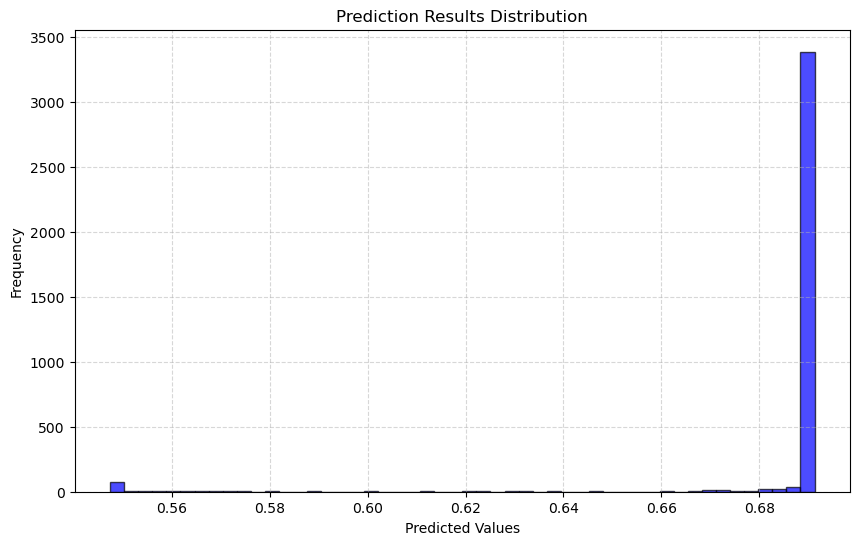

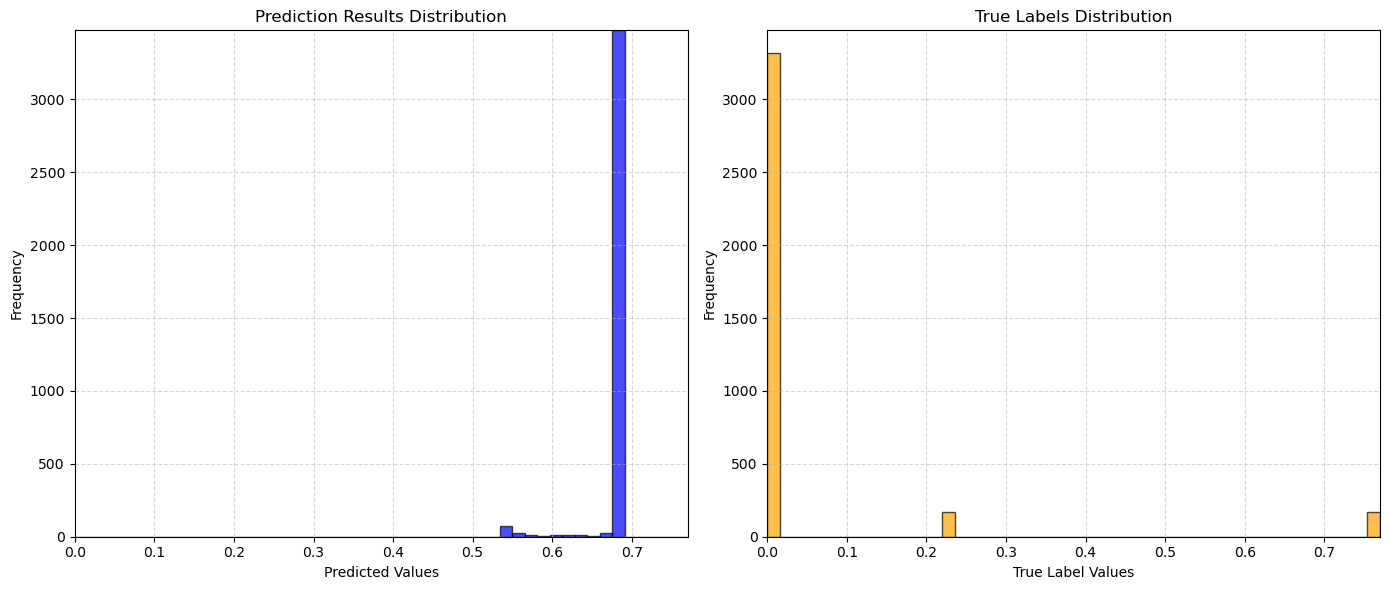

In [3]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin_src.weight)
        torch.nn.init.xavier_uniform_(m.lin_dst.weight)

# GATモデルの定義 (5層)
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy().flatten()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    """
    予測結果と教師データの分布を並べてヒストグラムで可視化し、
    横軸と縦軸を揃える関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - label_file_path (str): 教師データ（ラベル）のファイルパス。
    """
    # 教師データの読み込み
    true_labels = np.load(label_file_path)[:3654]  # 必要な範囲を指定
    # 予測結果の取得
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 両方のデータの最小値と最大値を計算
    combined_min = min(output_np.min(), true_labels.min())
    combined_max = max(output_np.max(), true_labels.max())

    # ビンの設定（両方のデータに共通のビンを使用）
    bins = np.linspace(combined_min, combined_max, 50)

    # 予測結果のヒストグラムの最大頻度を計算
    hist_pred, _ = np.histogram(output_np, bins=bins)
    hist_true, _ = np.histogram(true_labels, bins=bins)
    combined_max_freq = max(hist_pred.max(), hist_true.max())

    plt.figure(figsize=(14, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=bins, color='orange', alpha=0.7, edgecolor='black')
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_0.001524_20241007_192800.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")
    
# メイン関数
def main():
    model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_0.001524_20241007_192800.pth'
    file_path = "/home/nishioka/GNN/Defect_12x12_data/Defect_12x12_Normalized1/Normalized1_Defect12x12_ELNOD_L8B10.npy"
    label_file_path = "/home/nishioka/GNN/Defect_12x12_data/DefectLabels_12x12test2/12x12DefectLabel1_L8B10.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    
    # モデルのロード
    model = load_trained_model(model_path)

    # モデルのパラメータを確認（オプション）
    # check_model_parameters(model)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)  # オプション
    plot_predictions_and_labels(output, label_file_path)  # 横軸と縦軸を揃えたヒストグラム

if __name__ == "__main__":
    main()


Model file found at: /home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_194454.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.6677, True: 0.0000
Predicted: 0.6678, True: 0.0000
Predicted: 0.6680, True: 0.0000
Predicted: 0.6686, True: 0.0000
Predicted: 0.6697, True: 0.0000
Predicted: 0.6712, True: 0.0000
Predicted: 0.6728, True: 0.0000
Predicted: 0.6744, True: 0.0000
Predicted: 0.6760, True: 0.0000
Predicted: 0.6775, True: 0.0000

Output Stats: min=0.6432, max=0.7326, mean=0.6881
Label Stats: min=0.0000, max=0.7700, mean=0.0463


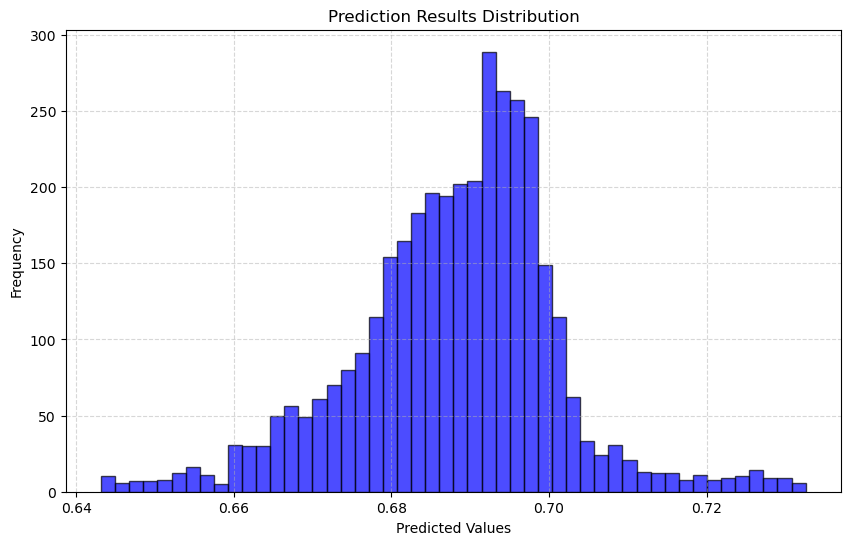

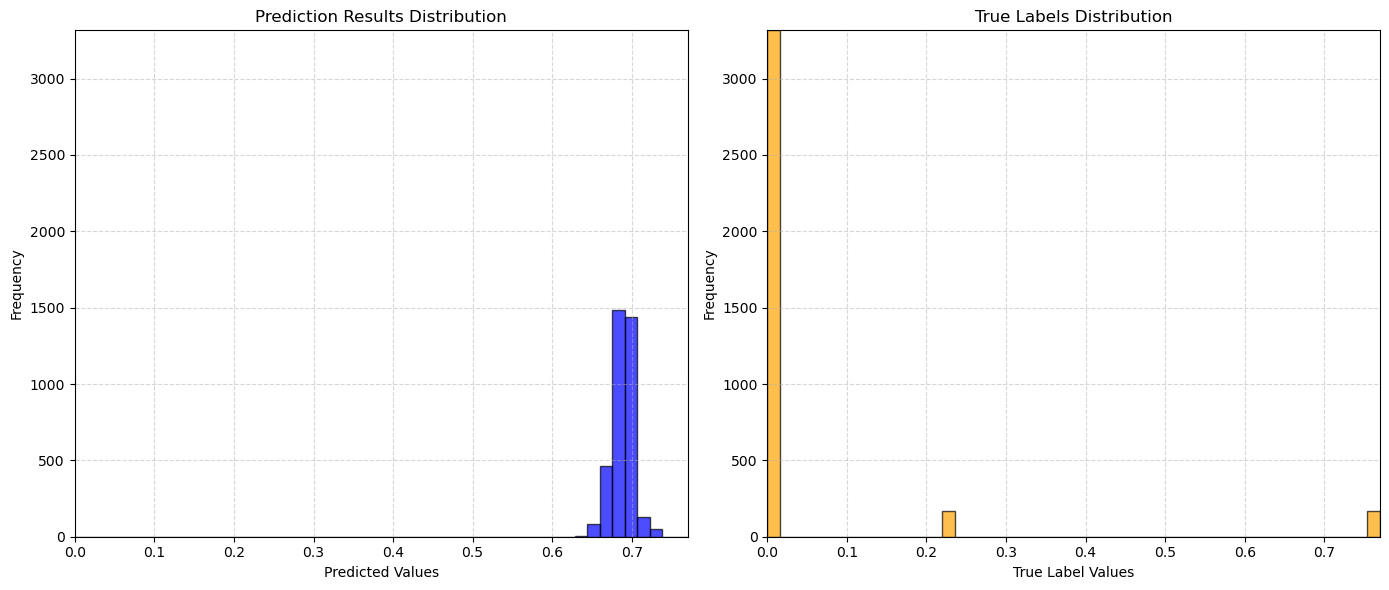

In [4]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin_src.weight)
        torch.nn.init.xavier_uniform_(m.lin_dst.weight)

# GATモデルの定義 (5層)
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy().flatten()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    """
    予測結果と教師データの分布を並べてヒストグラムで可視化し、
    横軸と縦軸を揃える関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - label_file_path (str): 教師データ（ラベル）のファイルパス。
    """
    # 教師データの読み込み
    true_labels = np.load(label_file_path)[:3654]  # 必要な範囲を指定
    # 予測結果の取得
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 両方のデータの最小値と最大値を計算
    combined_min = min(output_np.min(), true_labels.min())
    combined_max = max(output_np.max(), true_labels.max())

    # ビンの設定（両方のデータに共通のビンを使用）
    bins = np.linspace(combined_min, combined_max, 50)

    # 予測結果のヒストグラムの最大頻度を計算
    hist_pred, _ = np.histogram(output_np, bins=bins)
    hist_true, _ = np.histogram(true_labels, bins=bins)
    combined_max_freq = max(hist_pred.max(), hist_true.max())

    plt.figure(figsize=(14, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=bins, color='orange', alpha=0.7, edgecolor='black')
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_194454.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")
    
# メイン関数
def main():
    model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_194454.pth'
    file_path = "/home/nishioka/GNN/Defect_12x12_data/Defect_12x12_Normalized1/Normalized1_Defect12x12_ELNOD_L8B10.npy"
    label_file_path = "/home/nishioka/GNN/Defect_12x12_data/DefectLabels_12x12test2/12x12DefectLabel1_L8B10.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    
    # モデルのロード
    model = load_trained_model(model_path)

    # モデルのパラメータを確認（オプション）
    # check_model_parameters(model)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)  # オプション
    plot_predictions_and_labels(output, label_file_path)  # 横軸と縦軸を揃えたヒストグラム

if __name__ == "__main__":
    main()

Model file found at: /home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_0.000280_20241007_194825.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000
Predicted: 0.6665, True: 0.0000

Output Stats: min=0.6665, max=0.6665, mean=0.6665
Label Stats: min=0.0000, max=0.7700, mean=0.0463


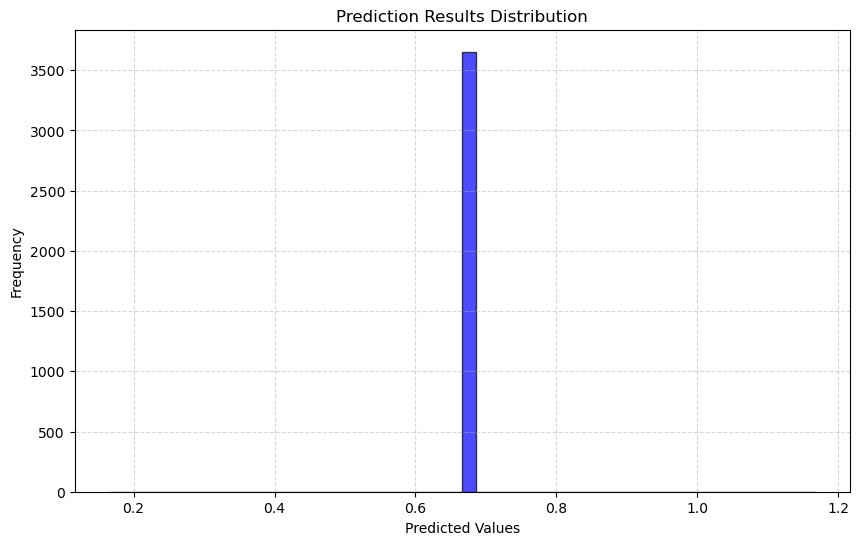

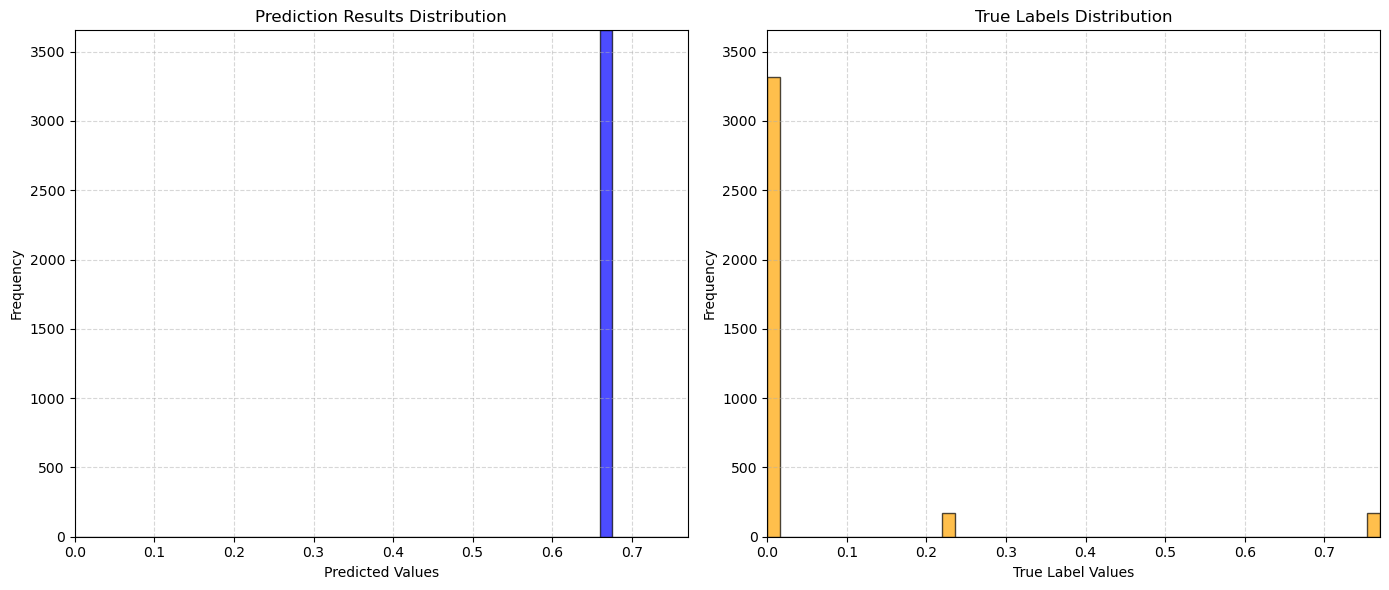

In [5]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin_src.weight)
        torch.nn.init.xavier_uniform_(m.lin_dst.weight)

# GATモデルの定義 (5層)
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy().flatten()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    """
    予測結果と教師データの分布を並べてヒストグラムで可視化し、
    横軸と縦軸を揃える関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - label_file_path (str): 教師データ（ラベル）のファイルパス。
    """
    # 教師データの読み込み
    true_labels = np.load(label_file_path)[:3654]  # 必要な範囲を指定
    # 予測結果の取得
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 両方のデータの最小値と最大値を計算
    combined_min = min(output_np.min(), true_labels.min())
    combined_max = max(output_np.max(), true_labels.max())

    # ビンの設定（両方のデータに共通のビンを使用）
    bins = np.linspace(combined_min, combined_max, 50)

    # 予測結果のヒストグラムの最大頻度を計算
    hist_pred, _ = np.histogram(output_np, bins=bins)
    hist_true, _ = np.histogram(true_labels, bins=bins)
    combined_max_freq = max(hist_pred.max(), hist_true.max())

    plt.figure(figsize=(14, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=bins, color='orange', alpha=0.7, edgecolor='black')
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_0.000280_20241007_194825.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")
    
# メイン関数
def main():
    model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_final_0.000280_20241007_194825.pth'
    file_path = "/home/nishioka/GNN/Defect_12x12_data/Defect_12x12_Normalized1/Normalized1_Defect12x12_ELNOD_L8B10.npy"
    label_file_path = "/home/nishioka/GNN/Defect_12x12_data/DefectLabels_12x12test2/12x12DefectLabel1_L8B10.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    
    # モデルのロード
    model = load_trained_model(model_path)

    # モデルのパラメータを確認（オプション）
    # check_model_parameters(model)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)  # オプション
    plot_predictions_and_labels(output, label_file_path)  # 横軸と縦軸を揃えたヒストグラム

if __name__ == "__main__":
    main()

Model file found at: /home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.0017, True: 0.0000
Predicted: 0.0017, True: 0.0000
Predicted: 0.0020, True: 0.0000
Predicted: 0.0028, True: 0.0000
Predicted: 0.0037, True: 0.0000
Predicted: 0.0039, True: 0.0000
Predicted: 0.0037, True: 0.0000
Predicted: 0.0033, True: 0.0000
Predicted: 0.0030, True: 0.0000
Predicted: 0.0028, True: 0.0000

Output Stats: min=0.0000, max=0.1923, mean=0.0174
Label Stats: min=0.0000, max=0.7700, mean=0.0463


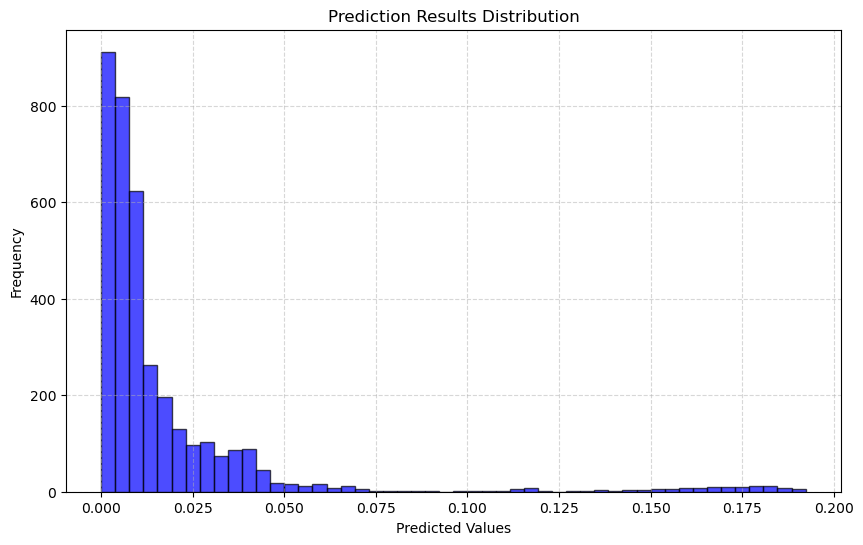

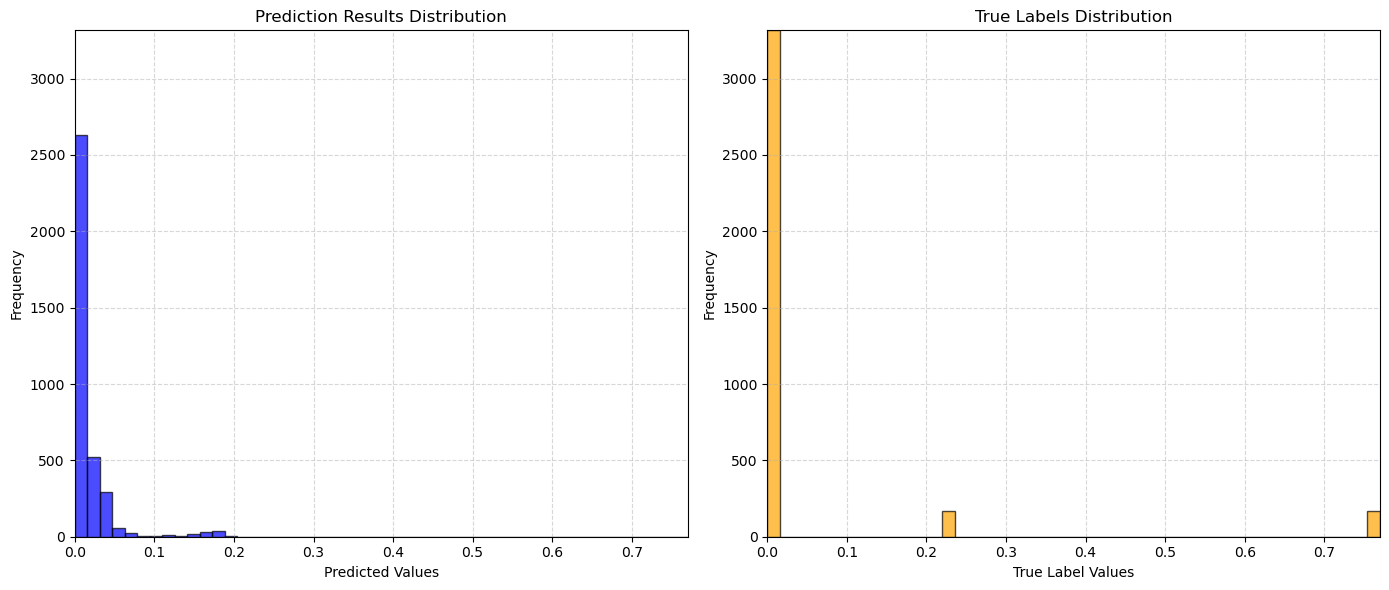

Predictions saved to /home/nishioka/GNN/Defect_12x12_data/GNNtraining_predictiondata/12x12prediction1_L8B10.npy


In [2]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin_src.weight)
        torch.nn.init.xavier_uniform_(m.lin_dst.weight)

# GATモデルの定義 (5層)
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy().flatten()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    """
    予測結果と教師データの分布を並べてヒストグラムで可視化し、
    横軸と縦軸を揃える関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - label_file_path (str): 教師データ（ラベル）のファイルパス。
    """
    # 教師データの読み込み
    true_labels = np.load(label_file_path)[:3654]  # 必要な範囲を指定
    # 予測結果の取得
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 両方のデータの最小値と最大値を計算
    combined_min = min(output_np.min(), true_labels.min())
    combined_max = max(output_np.max(), true_labels.max())

    # ビンの設定（両方のデータに共通のビンを使用）
    bins = np.linspace(combined_min, combined_max, 50)

    # 予測結果のヒストグラムの最大頻度を計算
    hist_pred, _ = np.histogram(output_np, bins=bins)
    hist_true, _ = np.histogram(true_labels, bins=bins)
    combined_max_freq = max(hist_pred.max(), hist_true.max())

    plt.figure(figsize=(14, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=bins, color='orange', alpha=0.7, edgecolor='black')
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def save_predictions(output, save_path):
    """
    予測結果を指定されたパスに .npy ファイルとして保存する関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - save_path (str): 保存先のファイルパス。
    """
    # テンソルを NumPy 配列に変換
    output_np = output.detach().cpu().numpy()
    
    # .npy ファイルとして保存
    np.save(save_path, output_np)
    
    print(f"Predictions saved to {save_path}")

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")
    
# メイン関数
def main():
    model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth'
    file_path = "/home/nishioka/GNN/Defect_12x12_data/Defect_12x12_Normalized1/Normalized1_Defect12x12_ELNOD_L8B10.npy"
    label_file_path = "/home/nishioka/GNN/Defect_12x12_data/DefectLabels_12x12test2/12x12DefectLabel1_L8B10.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    save_path = "/home/nishioka/GNN/Defect_12x12_data/GNNtraining_predictiondata/12x12prediction1_L8B10.npy"  # 保存先のパスを指定
    
    # モデルのロード
    model = load_trained_model(model_path)

    # モデルのパラメータを確認（オプション）
    # check_model_parameters(model)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)  # オプション
    plot_predictions_and_labels(output, label_file_path)  # 横軸と縦軸を揃えたヒストグラム

    save_predictions(output, save_path)

if __name__ == "__main__":
    main()

In [6]:
import numpy as np

# ファイルパスをダブルクォートで囲む
file_path = "/home/nishioka/GNN/Defect_12x12_data/GNNtraining_predictiondata/12x12prediction1_L8B10.npy"

# ファイルを読み込む
data = np.load(file_path)

# データを表示する
print(data)
print(data.shape)

[[0.00168395]
 [0.00173859]
 [0.00204563]
 ...
 [0.00764482]
 [0.00563399]
 [0.00337445]]
(3654, 1)


Model file found at: /home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.0017, True: 0.0000
Predicted: 0.0017, True: 0.0000
Predicted: 0.0020, True: 0.0000
Predicted: 0.0028, True: 0.0000
Predicted: 0.0037, True: 0.0000
Predicted: 0.0039, True: 0.0000
Predicted: 0.0037, True: 0.0000
Predicted: 0.0033, True: 0.0000
Predicted: 0.0030, True: 0.0000
Predicted: 0.0028, True: 0.0000

Output Stats: min=0.0000, max=0.1923, mean=0.0174
Label Stats: min=0.0000, max=0.7700, mean=0.0463


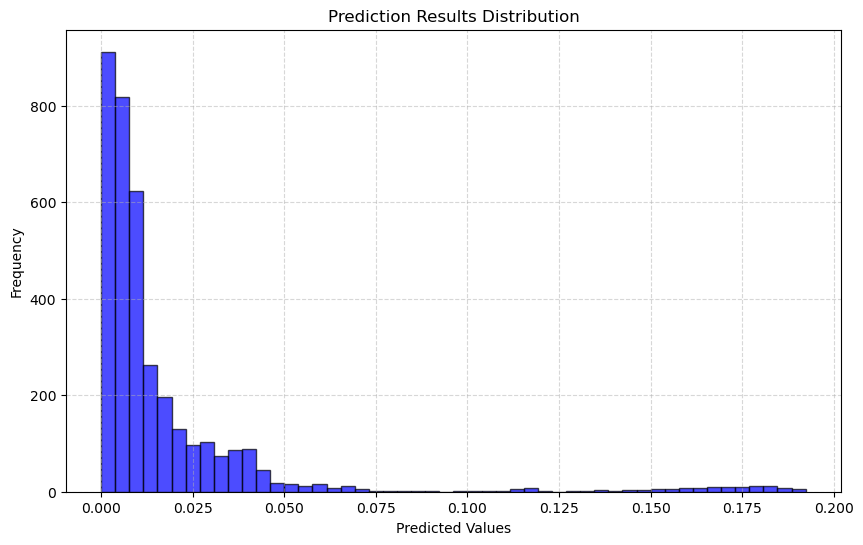

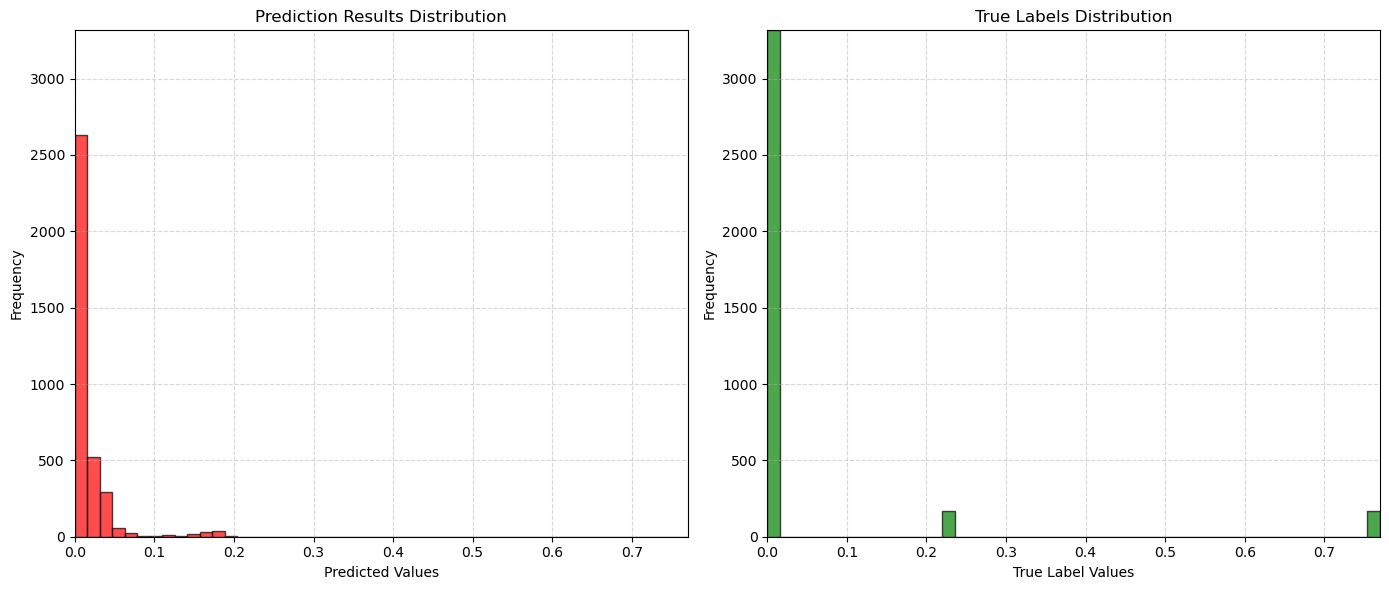

Predictions saved to /home/nishioka/GNN/Defect_12x12_data/GNNtraining_predictiondata/12x12prediction1_L8B10.npy with shape (3654,)


In [9]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin_src.weight)
        torch.nn.init.xavier_uniform_(m.lin_dst.weight)

# GATモデルの定義 (5層)
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy().flatten()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    """
    予測結果と教師データの分布を並べてヒストグラムで可視化し、
    横軸と縦軸を揃える関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - label_file_path (str): 教師データ（ラベル）のファイルパス。
    """
    # 教師データの読み込み
    true_labels = np.load(label_file_path)[:3654]  # 必要な範囲を指定
    # 予測結果の取得
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 両方のデータの最小値と最大値を計算
    combined_min = min(output_np.min(), true_labels.min())
    combined_max = max(output_np.max(), true_labels.max())

    # ビンの設定（両方のデータに共通のビンを使用）
    bins = np.linspace(combined_min, combined_max, 50)

    # 予測結果のヒストグラムの最大頻度を計算
    hist_pred, _ = np.histogram(output_np, bins=bins)
    hist_true, _ = np.histogram(true_labels, bins=bins)
    combined_max_freq = max(hist_pred.max(), hist_true.max())

    plt.figure(figsize=(14, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=bins, color='red', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=bins, color='green', alpha=0.7, edgecolor='black')
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def save_predictions(output, save_path):
    """
    予測結果を指定されたパスに1次元配列として .npy ファイルに保存する関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - save_path (str): 保存先のファイルパス。
    """
    try:
        # 保存先のディレクトリを取得
        directory = os.path.dirname(save_path)
        
        # ディレクトリが存在しない場合は作成
        if not os.path.exists(directory):
            os.makedirs(directory)
            print(f"Created directory: {directory}")
        
        # テンソルを NumPy 配列に変換し、1次元にリシェイプ
        output_np = output.detach().cpu().numpy().flatten()
        
        # .npy ファイルとして保存
        np.save(save_path, output_np)
        
        print(f"Predictions saved to {save_path} with shape {output_np.shape}")
    except Exception as e:
        print(f"Failed to save predictions: {e}")

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")

# メイン関数
def main():
    model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth'
    file_path = "/home/nishioka/GNN/Defect_12x12_data/Defect_12x12_Normalized1/Normalized1_Defect12x12_ELNOD_L8B10.npy"
    label_file_path = "/home/nishioka/GNN/Defect_12x12_data/DefectLabels_12x12test2/12x12DefectLabel1_L8B10.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    save_path = "/home/nishioka/GNN/Defect_12x12_data/GNNtraining_predictiondata/12x12prediction1_L8B10.npy"  # 保存先のパスを指定
    
    # モデルのロード
    model = load_trained_model(model_path)

    # モデルのパラメータを確認（オプション）
    # check_model_parameters(model)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)  # オプション
    plot_predictions_and_labels(output, label_file_path)  # 横軸と縦軸を揃えたヒストグラム

    # 予測結果を保存（1次元配列として保存）
    save_predictions(output, save_path)

if __name__ == "__main__":
    main()

Model file found at: /home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth
Predicted vs True Labels (First 10 Samples):
Predicted: 0.0029, True: 0.0000
Predicted: 0.0031, True: 0.0000
Predicted: 0.0039, True: 0.0000
Predicted: 0.0070, True: 0.0000
Predicted: 0.0143, True: 0.0000
Predicted: 0.0230, True: 0.0000
Predicted: 0.0280, True: 0.0000
Predicted: 0.0301, True: 0.0000
Predicted: 0.0320, True: 0.0000
Predicted: 0.0344, True: 0.0000

Output Stats: min=0.0001, max=0.1421, mean=0.0544
Label Stats: min=0.0000, max=0.0000, mean=0.0000


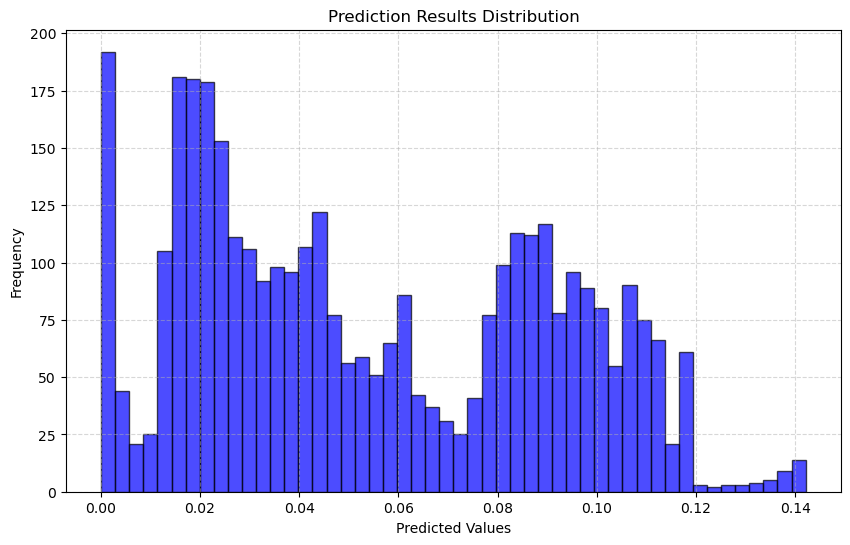

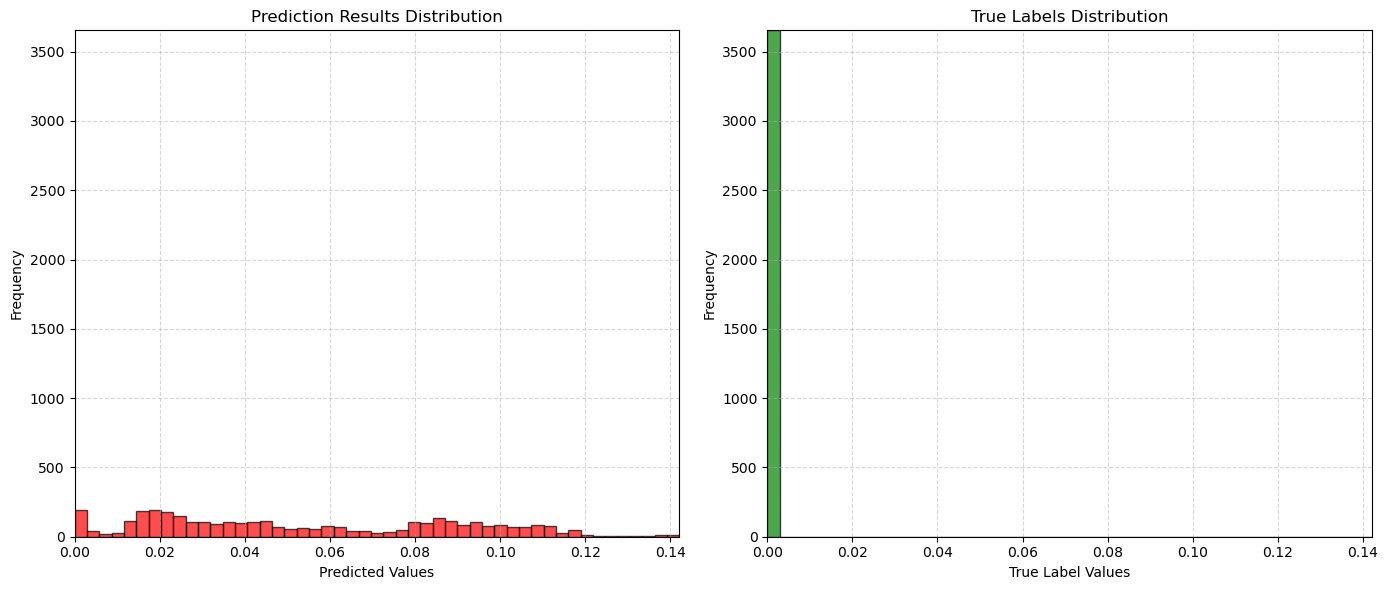

Predictions saved to /home/nishioka/GNN/Defect_12x12_data/GNNtraining_predictiondata/12x12prediction1_nodefect.npy with shape (3654,)


In [3]:
import os
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import torch.nn.functional as F
import matplotlib.pyplot as plt

# デバイスをCPUに固定
device = torch.device("cpu")

# Xavier初期化関数
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
    elif isinstance(m, GATConv):  # 変更
        torch.nn.init.xavier_uniform_(m.lin_src.weight)
        torch.nn.init.xavier_uniform_(m.lin_dst.weight)

# GATモデルの定義 (5層)
class GATModel(torch.nn.Module):  # 変更
    def __init__(self, hidden_channels=64):
        super(GATModel, self).__init__()
        self.conv1 = GATConv(4, hidden_channels, heads=4)  
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels * 2, heads=4)  
        self.conv3 = GATConv(hidden_channels * 8, hidden_channels * 4, heads=4)  
        self.conv4 = GATConv(hidden_channels * 16, hidden_channels, heads=4)  
        self.conv5 = GATConv(hidden_channels * 4, hidden_channels)  # 新しい5層目
        self.fc_defect = torch.nn.Linear(hidden_channels, 1)  # 回帰タスク用に出力1次元

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = F.relu(self.conv4(x, edge_index))
        x = F.relu(self.conv5(x, edge_index))  # 新しい5層目
        x = self.fc_defect(x)  
        return torch.sigmoid(x)  

# 学習済みモデルのロード
def load_trained_model(model_path):
    model = GATModel()
    model.load_state_dict(torch.load(model_path, map_location=device))  # CPUにマップしてロード
    model.to(device)  # モデルをCPUに移動
    model.eval()  # 評価モードに設定
    return model

# モデルのパラメータを確認する
def check_model_parameters(model):
    for name, param in model.named_parameters():
        print(f"Layer: {name}, Shape: {param.shape}, Values: {param[:2]}")  # パラメータの形状と最初の2つの値を表示

# データの準備
def prepare_test_data(file_path, edge_path):
    # 入力データの読み込み (x, y, z 座標と主応力データ)
    x_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/x_2layer_normalized.npy")[:3654]
    y_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/y_2layer_normalized.npy")[:3654]
    z_coords = np.load("/home/nishioka/GNN/BasicdataforGNN/z_2layer_normalized.npy")[:3654]
    stress_values = np.load(file_path)  # 主応力データ

    # エッジ情報の読み込み
    edges = np.load(edge_path)

    # ノード特徴量 (x, y, z, 主応力) を結合
    node_features = np.vstack((x_coords, y_coords, z_coords, stress_values)).T

    # データを PyTorch のテンソルに変換
    input_data = torch.tensor(node_features, dtype=torch.float)
    edge_index = torch.tensor(edges.T, dtype=torch.long)

    # torch_geometric の Data オブジェクトに変換し、CPUに移動
    data = Data(x=input_data, edge_index=edge_index).to(device)
    return data

# 予測を実行し、結果を表示する関数
def predict(model, data):
    model.eval()
    with torch.no_grad():  # 勾配計算を無効にして予測
        output = model(data)
    return output

# 予測結果と教師データの比較
def compare_with_labels(output, label_file_path):
    # 出力と教師データを比較
    true_labels = np.load(label_file_path)[:3654]  # ラベルを読み込む
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 予測結果と教師データの最初の10個を比較表示
    print("Predicted vs True Labels (First 10 Samples):")
    for i in range(10):
        print(f"Predicted: {output_np[i]:.4f}, True: {true_labels[i]:.4f}")

    # 統計情報を表示
    print(f"\nOutput Stats: min={output_np.min():.4f}, max={output_np.max():.4f}, mean={output_np.mean():.4f}")
    print(f"Label Stats: min={true_labels.min():.4f}, max={true_labels.max():.4f}, mean={true_labels.mean():.4f}")

# 予測結果を表示・プロット
def plot_predictions(output):
    output_np = output.detach().cpu().numpy().flatten()
    plt.figure(figsize=(10, 6))
    plt.hist(output_np, bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 予測結果と教師データの分布をヒストグラムで可視化
def plot_predictions_and_labels(output, label_file_path):
    """
    予測結果と教師データの分布を並べてヒストグラムで可視化し、
    横軸と縦軸を揃える関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - label_file_path (str): 教師データ（ラベル）のファイルパス。
    """
    # 教師データの読み込み
    true_labels = np.load(label_file_path)[:3654]  # 必要な範囲を指定
    # 予測結果の取得
    output_np = output.detach().cpu().numpy().flatten()  # 一次元配列に変換

    # 両方のデータの最小値と最大値を計算
    combined_min = min(output_np.min(), true_labels.min())
    combined_max = max(output_np.max(), true_labels.max())

    # ビンの設定（両方のデータに共通のビンを使用）
    bins = np.linspace(combined_min, combined_max, 50)

    # 予測結果のヒストグラムの最大頻度を計算
    hist_pred, _ = np.histogram(output_np, bins=bins)
    hist_true, _ = np.histogram(true_labels, bins=bins)
    combined_max_freq = max(hist_pred.max(), hist_true.max())

    plt.figure(figsize=(14, 6))

    # 予測結果のヒストグラム
    plt.subplot(1, 2, 1)
    plt.hist(output_np, bins=bins, color='red', alpha=0.7, edgecolor='black')
    plt.title("Prediction Results Distribution")
    plt.xlabel("Predicted Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    # 教師データのヒストグラム
    plt.subplot(1, 2, 2)
    plt.hist(true_labels, bins=bins, color='green', alpha=0.7, edgecolor='black')
    plt.title("True Labels Distribution")
    plt.xlabel("True Label Values")
    plt.ylabel("Frequency")
    plt.xlim(combined_min, combined_max)  # 横軸の範囲を統一
    plt.ylim(0, combined_max_freq)       # 縦軸の範囲を統一
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

def save_predictions(output, save_path):
    """
    予測結果を指定されたパスに1次元配列として .npy ファイルに保存する関数。

    Parameters:
    - output (torch.Tensor): モデルの予測結果。
    - save_path (str): 保存先のファイルパス。
    """
    try:
        # 保存先のディレクトリを取得
        directory = os.path.dirname(save_path)
        
        # ディレクトリが存在しない場合は作成
        if not os.path.exists(directory):
            os.makedirs(directory)
            print(f"Created directory: {directory}")
        
        # テンソルを NumPy 配列に変換し、1次元にリシェイプ
        output_np = output.detach().cpu().numpy().flatten()
        
        # .npy ファイルとして保存
        np.save(save_path, output_np)
        
        print(f"Predictions saved to {save_path} with shape {output_np.shape}")
    except Exception as e:
        print(f"Failed to save predictions: {e}")

# モデルファイルが存在しているか確認
model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth'
if os.path.exists(model_path):
    print(f"Model file found at: {model_path}")
else:
    print(f"Model file not found: {model_path}")

# メイン関数
def main():
    model_path = '/home/nishioka/GNN/Defect_12x12_data/GNNmodel/GATModel_best_20241007_200323.pth'
    file_path = "/home/nishioka/GNN/BasicdataforGNN/Normalized1_nodefect_ElNOD.npy"
    label_file_path = "/home/nishioka/GNN/BasicdataforGNN/DefectLabel_nodefect.npy"
    edge_path = "/home/nishioka/GNN/BasicdataforGNN/edges_2layer.npy"
    save_path = "/home/nishioka/GNN/Defect_12x12_data/GNNtraining_predictiondata/12x12prediction1_nodefect.npy"  # 保存先のパスを指定
    
    # モデルのロード
    model = load_trained_model(model_path)

    # モデルのパラメータを確認（オプション）
    # check_model_parameters(model)

    # テストデータの準備
    data = prepare_test_data(file_path, edge_path)

    # 予測を実行
    output = predict(model, data)

    # 予測結果の表示
    compare_with_labels(output, label_file_path)

    # プロット表示
    plot_predictions(output)  # オプション
    plot_predictions_and_labels(output, label_file_path)  # 横軸と縦軸を揃えたヒストグラム

    # 予測結果を保存（1次元配列として保存）
    save_predictions(output, save_path)

if __name__ == "__main__":
    main()